# Adult Income Prediction — Modelling Pipeline with Class Weights = "balanced" and Hyperparameter Tuning

In [1]:
# =============================================================================
# STEP 0: Imports
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})


---
## STEP 1 — Load Preprocessed Data
Load the train/val/test splits saved by `EDA_Preprocessing.ipynb`.


In [2]:
# =============================================================================
# STEP 1 — Load Preprocessed Data
# =============================================================================
# NOTE: You must run EDA_Preprocessing.ipynb first (including the save cell)
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).to_string())


Train: (32542, 41), Test: (16248, 41)
Train class distribution:
0    0.760586
1    0.239414


---
## STEP 2 — Reusable Evaluation Function
Primary metric: **F1-Score (weighted)**. Secondary: ROC-AUC, Accuracy, Precision, Recall.


In [3]:
# =============================================================================
# STEP 2 — Evaluation Helper
# =============================================================================
all_results = []  # collect results for final comparison

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate a fitted model and print all required metrics."""
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, average="weighted")
    f1   = f1_score(y_test, y_pred, average="weighted")
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*60}")
    print(f"  Evaluation: {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}  << PRIMARY")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["<=50K", ">50K"],
        cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{model_name} - Confusion Matrix")
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
    axes[1].set_title(f"{model_name} - ROC Curve")
    plt.tight_layout()
    plt.show()

    result = {"Model": model_name, "Accuracy": acc, "Precision": prec,
              "Recall": rec, "F1-Score": f1, "ROC-AUC": auc}
    all_results.append(result)
    return result


---
## STEP 3 — 5-Fold Cross Validation Setup

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_cv(model, X, y, model_name):
    scores = cross_validate(
        model, X, y, cv=cv,
        scoring=[
            "f1_weighted", 
            "roc_auc", 
            "accuracy", 
            "precision_weighted", 
            "recall_weighted"
        ],
        n_jobs=-1
    )
    print(f"\n{'='*90}")
    print(f"  CV Results: {model_name}")
    print(f"{'='*90}")
    print(f"  Accuracy  : {scores['test_accuracy'].mean():.4f}  ± {scores['test_accuracy'].std():.4f}")
    print(f"  Precision : {scores['test_precision_weighted'].mean():.4f}  ± {scores['test_precision_weighted'].std():.4f}")
    print(f"  Recall    : {scores['test_recall_weighted'].mean():.4f}  ± {scores['test_recall_weighted'].std():.4f}")
    print(f"  F1-Score  : {scores['test_f1_weighted'].mean():.4f}  ± {scores['test_f1_weighted'].std():.4f}  << PRIMARY")
    print(f"  ROC-AUC   : {scores['test_roc_auc'].mean():.4f}  ± {scores['test_roc_auc'].std():.4f}")
    
    return {
        "Model": model_name,
        "CV Accuracy": round(scores["test_accuracy"].mean(), 4),
        "CV Precision": round(scores["test_precision_weighted"].mean(), 4),
        "CV Recall": round(scores["test_recall_weighted"].mean(), 4),
        "CV F1-Score": round(scores["test_f1_weighted"].mean(), 4),
        "CV ROC-AUC":  round(scores["test_roc_auc"].mean(), 4),
    }


---
## STEP 4 — 5-Fold Cross Validation Outputs

In [5]:
cv_results = []

# ── Logistic Regression ───────────────────────────────────────────────────────
cv_results.append(run_cv(
    LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs", class_weight="balanced"),
    X_train, y_train, "Logistic Regression"
))

# ── Decision Tree ─────────────────────────────────────────────────────────────
cv_results.append(run_cv(
    DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    X_train, y_train, "Decision Tree (depth=5)"
))

# ── Random Forest ─────────────────────────────────────────────────────────────
cv_results.append(run_cv(
    RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced"),
    X_train, y_train, "Random Forest (n=200)"
))

# ── XGBoost ───────────────────────────────────────────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
cv_results.append(run_cv(
    XGBClassifier(n_estimators=300, random_state=42,
                  eval_metric="logloss", n_jobs=-1, scale_pos_weight=neg/pos),
    X_train, y_train, "XGBoost (n=300)"
))

# ── Ensemble ──────────────────────────────────────────────────────────────────
cv_results.append(run_cv(
    VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs", class_weight="balanced")),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight="balanced")),
            ("xgb", XGBClassifier(n_estimators=300, random_state=42,
                                  eval_metric="logloss", n_jobs=-1, scale_pos_weight=neg/pos))
        ],
        voting="soft"
    ),
    X_train, y_train, "Soft Voting Ensemble"
))

# ── CV Summary ────────────────────────────────────────────────────────────────
cv_df = pd.DataFrame(cv_results).set_index("Model")
print("\n" + "="*90)
print("  CV COMPARISON SUMMARY")
print("="*90)
print(cv_df.to_string())


  CV Results: Logistic Regression
  Accuracy  : 0.8017  ± 0.0026
  Precision : 0.8497  ± 0.0023
  Recall    : 0.8017  ± 0.0026
  F1-Score  : 0.8133  ± 0.0023  << PRIMARY
  ROC-AUC   : 0.8986  ± 0.0023

  CV Results: Decision Tree (depth=5)
  Accuracy  : 0.7799  ± 0.0044
  Precision : 0.8481  ± 0.0030
  Recall    : 0.7799  ± 0.0044
  F1-Score  : 0.7945  ± 0.0038  << PRIMARY
  ROC-AUC   : 0.8890  ± 0.0030

  CV Results: Random Forest (n=200)
  Accuracy  : 0.8438  ± 0.0026
  Precision : 0.8403  ± 0.0019
  Recall    : 0.8438  ± 0.0026
  F1-Score  : 0.8417  ± 0.0021  << PRIMARY
  ROC-AUC   : 0.8938  ± 0.0023

  CV Results: XGBoost (n=300)
  Accuracy  : 0.8377  ± 0.0035
  Precision : 0.8619  ± 0.0024
  Recall    : 0.8377  ± 0.0035
  F1-Score  : 0.8446  ± 0.0031  << PRIMARY
  ROC-AUC   : 0.9187  ± 0.0013

  CV Results: Soft Voting Ensemble
  Accuracy  : 0.8505  ± 0.0036
  Precision : 0.8643  ± 0.0020
  Recall    : 0.8505  ± 0.0036
  F1-Score  : 0.8550  ± 0.0032  << PRIMARY
  ROC-AUC   : 0.91

---
## STEP 5 — Hyperparameter Tuning using GridSearchCV

In [6]:
# ── Logistic Regression ───────────────────────────────────────────────────────
lr_param_grid = {
    "C":       [0.01, 0.1, 1, 10],   # regularization strength
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],         # liblinear supports both l1 and l2
}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    lr_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)
print("LR        → best params:", lr_grid.best_params_)
print("LR        → best CV F1 :", round(lr_grid.best_score_, 4))

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_param_grid = {
    "max_depth":        [3, 5, 7, 10, None],
    "min_samples_split":[2, 5, 10],
    "criterion":        ["gini", "entropy"],
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    dt_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=1
)
dt_grid.fit(X_train, y_train)
print("DT        → best params:", dt_grid.best_params_)
print("DT        → best CV F1 :", round(dt_grid.best_score_, 4))

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_param_grid = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5, 10],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"),
    rf_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print("RF        → best params:", rf_grid.best_params_)
print("RF        → best CV F1 :", round(rf_grid.best_score_, 4))

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_param_grid = {
    "n_estimators":  [200, 300, 400, 500],
    "max_depth":     [3, 5, 7, 10],
    "learning_rate": [0.05, 0.1, 0.2, 0.3],
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss",
                  n_jobs=-1, scale_pos_weight=neg/pos),
    xgb_param_grid, cv=cv, scoring="f1_weighted", n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train, y_train)
print("XGBoost   → best params:", xgb_grid.best_params_)
print("XGBoost   → best CV F1 :", round(xgb_grid.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
LR        → best params: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
LR        → best CV F1 : 0.8132
Fitting 5 folds for each of 30 candidates, totalling 150 fits
DT        → best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
DT        → best CV F1 : 0.8274
Fitting 5 folds for each of 27 candidates, totalling 135 fits
RF        → best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
RF        → best CV F1 : 0.8484
Fitting 5 folds for each of 64 candidates, totalling 320 fits
XGBoost   → best params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}
XGBoost   → best CV F1 : 0.8472


---
## Model Evaluation



## STEP 6 — Majority-Class Baseline



  Evaluation: Majority-Class Baseline
  Accuracy : 0.7606
  Precision: 0.5785
  Recall   : 0.7606
  F1-Score : 0.6572  << PRIMARY
  ROC-AUC  : 0.5000

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.76      1.00      0.86     12358
        >50K       0.00      0.00      0.00      3890

    accuracy                           0.76     16248
   macro avg       0.38      0.50      0.43     16248
weighted avg       0.58      0.76      0.66     16248



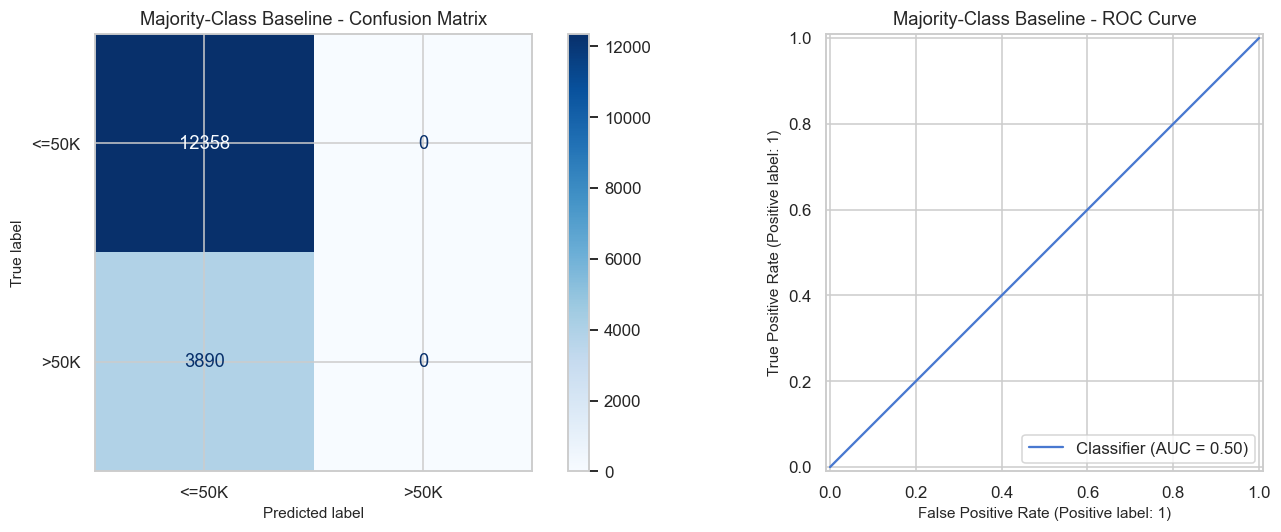

{'Model': 'Majority-Class Baseline',
 'Accuracy': 0.7605859182668636,
 'Precision': np.float64(0.5784909390658481),
 'Recall': np.float64(0.7605859182668636),
 'F1-Score': np.float64(0.6571572941300358),
 'ROC-AUC': np.float64(0.5)}

In [ ]:
# =============================================================================
# STEP 6 — Majority-Class Baseline
# =============================================================================
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
evaluate_model(baseline, X_test, y_test, "Majority-Class Baseline")


---
## STEP 7 — Logistic Regression + Coefficient Analysis



  Evaluation: Logistic Regression (Tuned)
  Accuracy : 0.7986
  Precision: 0.8479
  Recall   : 0.7986
  F1-Score : 0.8105  << PRIMARY
  ROC-AUC  : 0.8988

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.94      0.78      0.86     12358
        >50K       0.55      0.84      0.67      3890

    accuracy                           0.80     16248
   macro avg       0.75      0.81      0.76     16248
weighted avg       0.85      0.80      0.81     16248



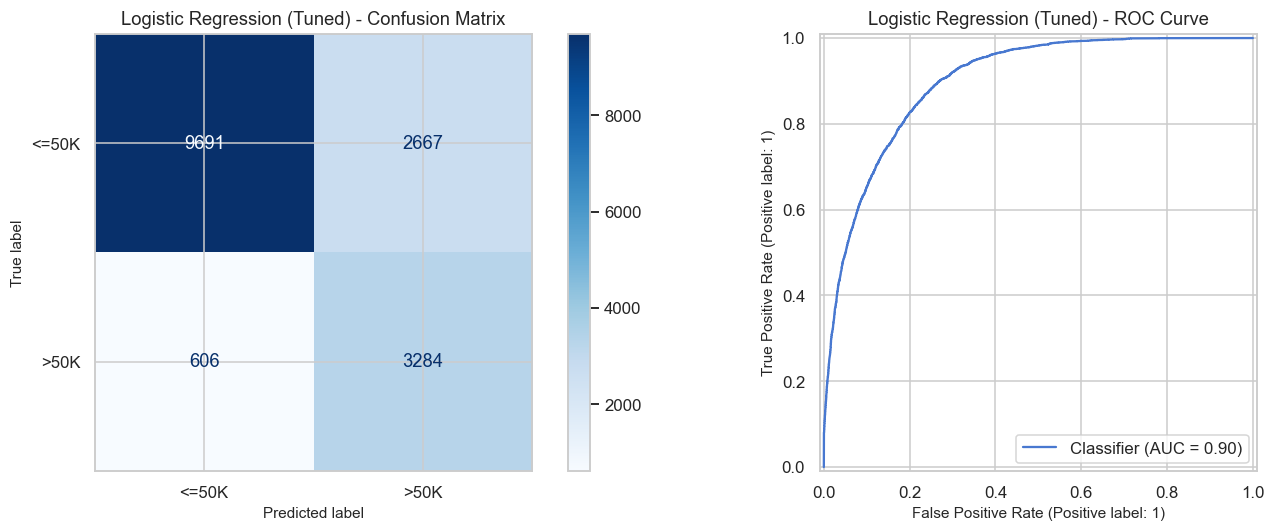

{'Model': 'Logistic Regression (Tuned)',
 'Accuracy': 0.7985598227474151,
 'Precision': np.float64(0.8479421184908245),
 'Recall': np.float64(0.7985598227474151),
 'F1-Score': np.float64(0.8104907861176153),
 'ROC-AUC': np.float64(0.8988423347843325)}

In [8]:
# =============================================================================
# STEP 7a — Logistic Regression
# =============================================================================
evaluate_model(lr_grid.best_estimator_,  X_test, y_test, "Logistic Regression (Tuned)")

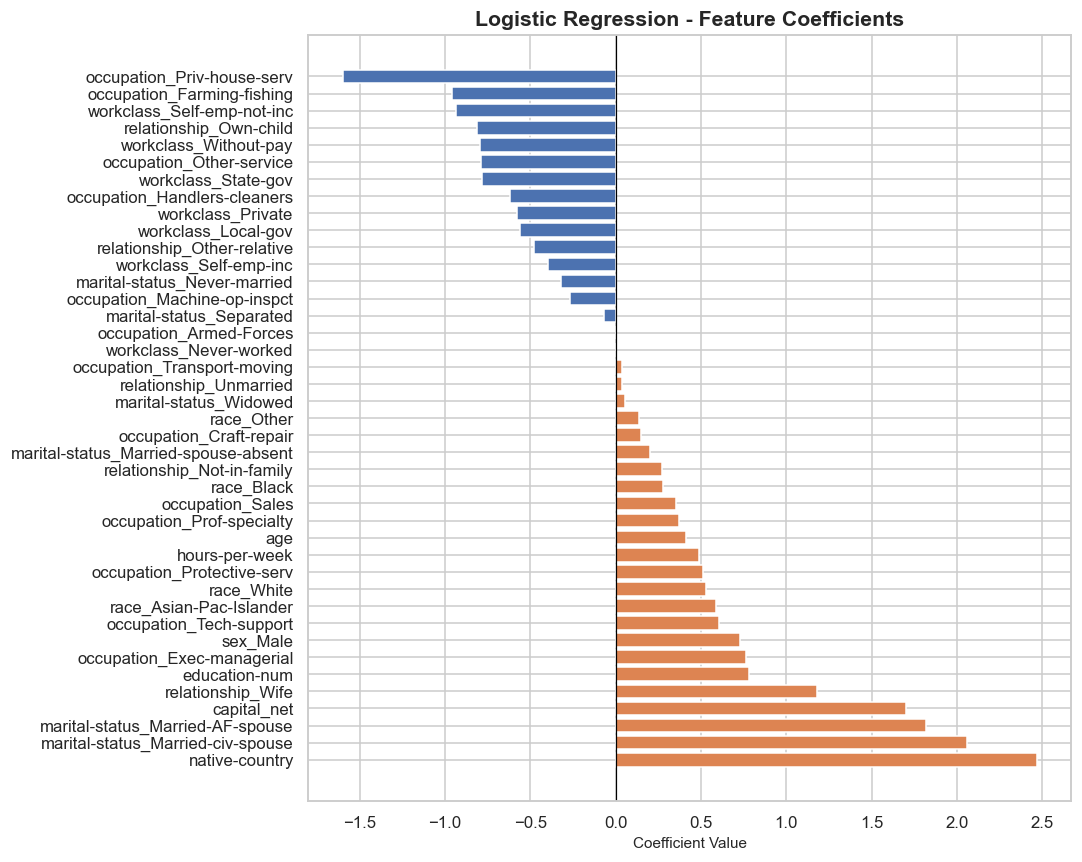


Top 5 features pushing towards >50K:
                          Feature  Coefficient
                   native-country     2.467274
marital-status_Married-civ-spouse     2.061097
 marital-status_Married-AF-spouse     1.818000
                      capital_net     1.699739
                relationship_Wife     1.180487

Top 5 features pushing towards <=50K:
                   Feature  Coefficient
     workclass_Without-pay    -0.792568
    relationship_Own-child    -0.810973
workclass_Self-emp-not-inc    -0.935882
occupation_Farming-fishing    -0.958485
occupation_Priv-house-serv    -1.597359


In [ ]:
# =============================================================================
# STEP 7b — Coefficient Analysis
# =============================================================================
coeffs = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_grid.best_estimator_.coef_[0]
}).sort_values("Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#DD8452" if c > 0 else "#4C72B0" for c in coeffs["Coefficient"]]
ax.barh(coeffs["Feature"], coeffs["Coefficient"], color=colors, edgecolor="white")
ax.set_title("Logistic Regression - Feature Coefficients", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient Value")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 5 features pushing towards >50K:")
print(coeffs.head(5).to_string(index=False))
print("\nTop 5 features pushing towards <=50K:")
print(coeffs.tail(5).to_string(index=False))


---
## STEP 8 — Decision Tree + Visualization



  Evaluation: Decision Tree (Tuned)
  Accuracy : 0.8206
  Precision: 0.8323
  Recall   : 0.8206
  F1-Score : 0.8250  << PRIMARY
  ROC-AUC  : 0.8700

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.90      0.86      0.88     12358
        >50K       0.61      0.71      0.65      3890

    accuracy                           0.82     16248
   macro avg       0.76      0.78      0.77     16248
weighted avg       0.83      0.82      0.83     16248



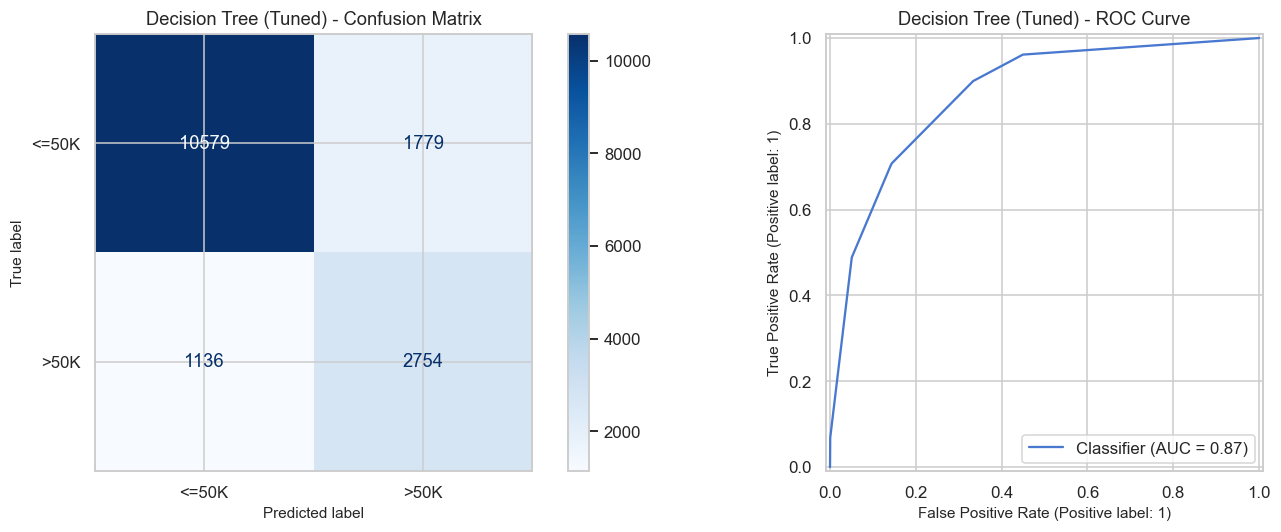

{'Model': 'Decision Tree (Tuned)',
 'Accuracy': 0.8205933037912359,
 'Precision': np.float64(0.8322868821081828),
 'Recall': np.float64(0.8205933037912359),
 'F1-Score': np.float64(0.8250451171803791),
 'ROC-AUC': np.float64(0.8700085724472684)}

In [10]:
# =============================================================================
# STEP 8a — Decision Tree
# =============================================================================
evaluate_model(dt_grid.best_estimator_,  X_test, y_test, "Decision Tree (Tuned)")

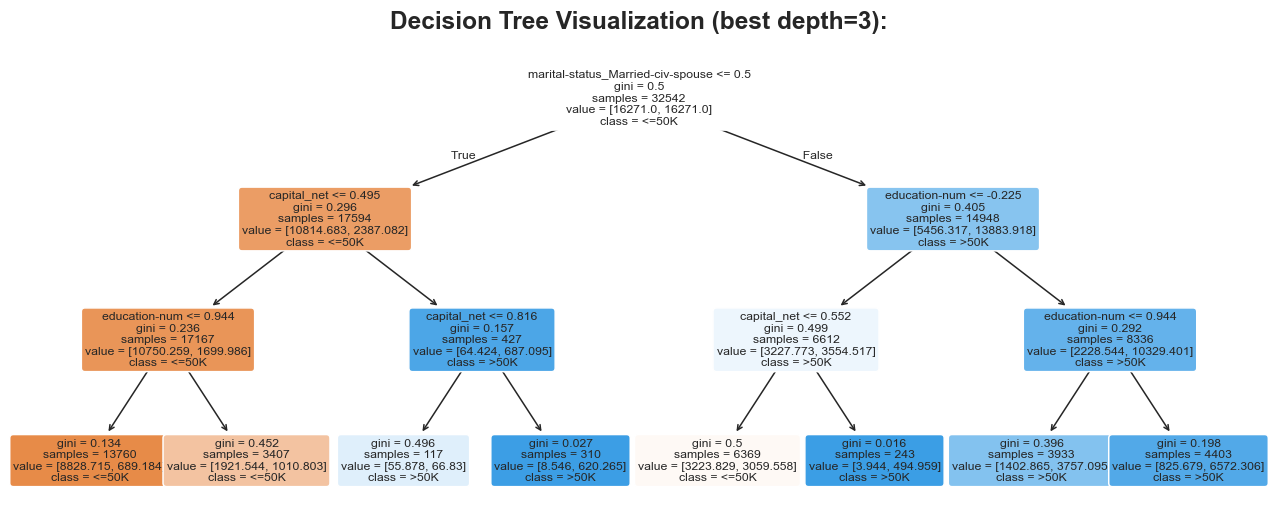

In [11]:
# =============================================================================
# STEP 8b — Tree Visualization
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(dt_grid.best_estimator_, feature_names=X_train.columns.tolist(),
          class_names=["<=50K", ">50K"], filled=True, rounded=True,
          fontsize=8, ax=ax)
ax.set_title(f"Decision Tree Visualization (best depth={dt_grid.best_estimator_.max_depth}):", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


---
## STEP 9 — Results Summary


In [12]:
# =============================================================================
# STEP 9 — Results Summary
# =============================================================================
wp4_df = pd.DataFrame(all_results).set_index("Model")
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(wp4_df.round(4).to_string())
print("\nPrimary metric: F1-Score (weighted)")



MODEL COMPARISON SUMMARY
                             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                      
Majority-Class Baseline        0.7606     0.5785  0.7606    0.6572   0.5000
Logistic Regression (Tuned)    0.7986     0.8479  0.7986    0.8105   0.8988
Decision Tree (Tuned)          0.8206     0.8323  0.8206    0.8250   0.8700

Primary metric: F1-Score (weighted)


---
# Advanced Models, Ensemble & Interpretation


## STEP 10 — SVM (RBF Kernel)
> Note: SVM can be slow on large datasets. Be patient.

Did not apply CV due to long processing time.



  Evaluation: SVM (RBF kernel)
  Accuracy : 0.8064
  Precision: 0.8556
  Recall   : 0.8064
  F1-Score : 0.8179  << PRIMARY
  ROC-AUC  : 0.9012

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86     12358
        >50K       0.56      0.86      0.68      3890

    accuracy                           0.81     16248
   macro avg       0.76      0.83      0.77     16248
weighted avg       0.86      0.81      0.82     16248



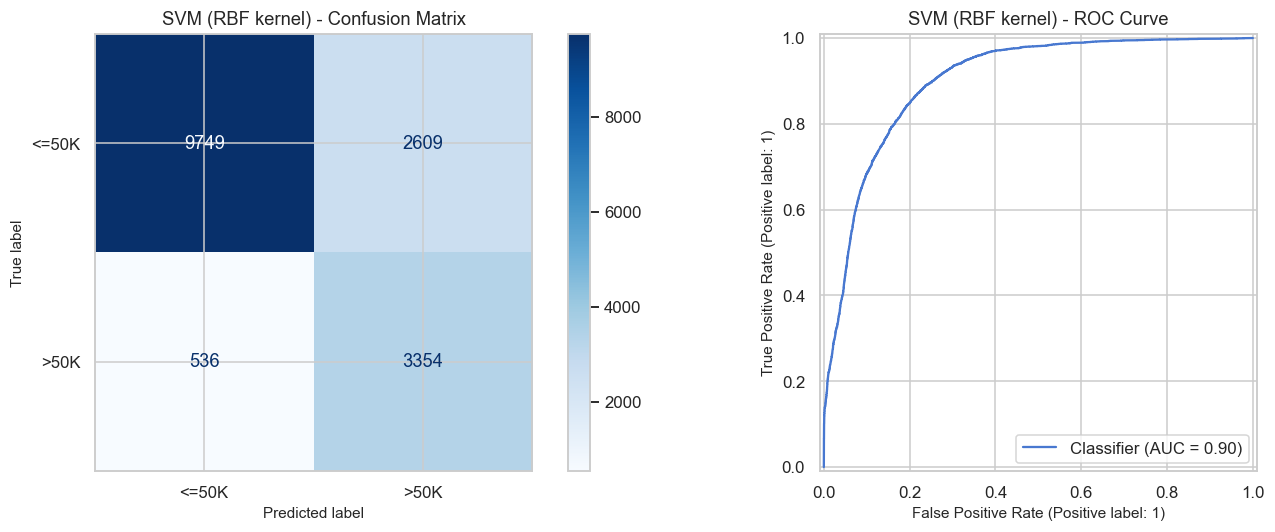

{'Model': 'SVM (RBF kernel)',
 'Accuracy': 0.8064377154111275,
 'Precision': np.float64(0.8556110812118486),
 'Recall': np.float64(0.8064377154111275),
 'F1-Score': np.float64(0.8179393122652557),
 'ROC-AUC': np.float64(0.9011630112941629)}

In [13]:
# =============================================================================
# STEP 10 — SVM (RBF kernel)
# =============================================================================
svm_model = SVC(kernel="rbf", probability=True, random_state=42, class_weight="balanced")
svm_model.fit(X_train, y_train)
evaluate_model(svm_model, X_test, y_test, "SVM (RBF kernel)")


---
## STEP 11 — Random Forest



  Evaluation: Random Forest (Tuned)
  Accuracy : 0.8426
  Precision: 0.8545
  Recall   : 0.8426
  F1-Score : 0.8468  << PRIMARY
  ROC-AUC  : 0.9115

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.92      0.87      0.89     12358
        >50K       0.65      0.76      0.70      3890

    accuracy                           0.84     16248
   macro avg       0.78      0.81      0.80     16248
weighted avg       0.85      0.84      0.85     16248



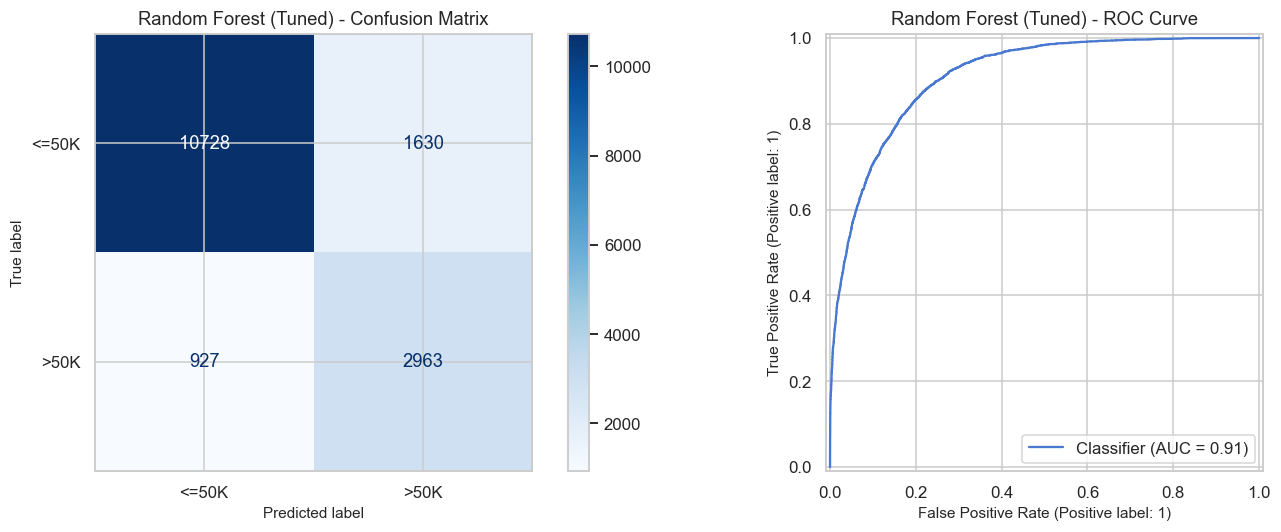

{'Model': 'Random Forest (Tuned)',
 'Accuracy': 0.8426267848350566,
 'Precision': np.float64(0.8545403673620912),
 'Recall': np.float64(0.8426267848350566),
 'F1-Score': np.float64(0.8468440578292203),
 'ROC-AUC': np.float64(0.9115240546489873)}

In [14]:
# =============================================================================
# STEP 11 — Random Forest
# =============================================================================
evaluate_model(rf_grid.best_estimator_,  X_test, y_test, "Random Forest (Tuned)")

---
## STEP 12 — XGBoost



  Evaluation: XGBoost (Tuned)
  Accuracy : 0.8364
  Precision: 0.8646
  Recall   : 0.8364
  F1-Score : 0.8440  << PRIMARY
  ROC-AUC  : 0.9268

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.89     12358
        >50K       0.62      0.84      0.71      3890

    accuracy                           0.84     16248
   macro avg       0.78      0.84      0.80     16248
weighted avg       0.86      0.84      0.84     16248



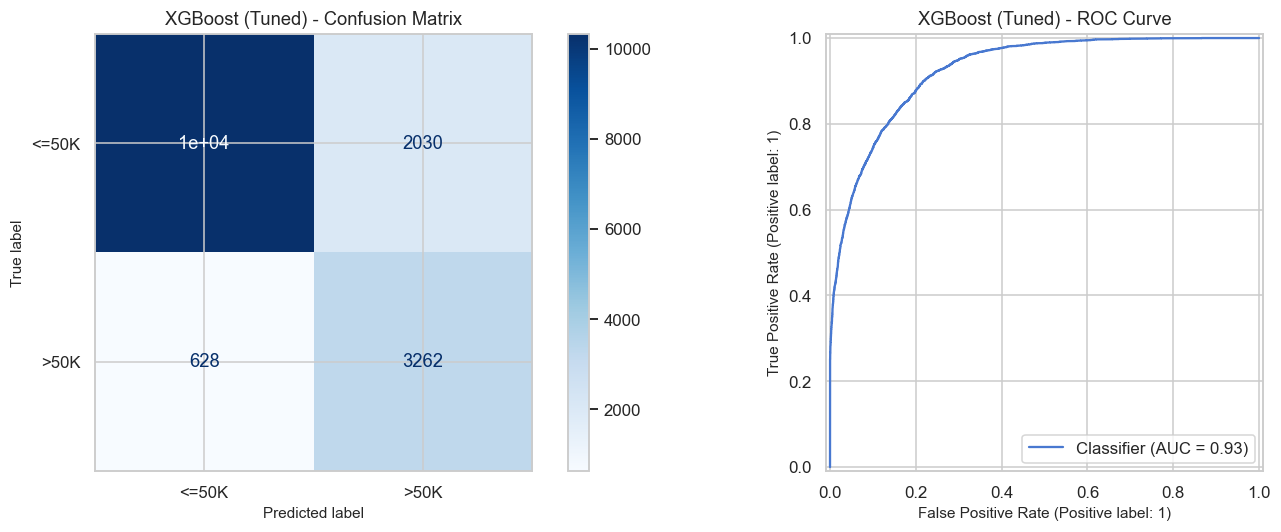

{'Model': 'XGBoost (Tuned)',
 'Accuracy': 0.8364106351550961,
 'Precision': np.float64(0.864564335711109),
 'Recall': np.float64(0.8364106351550961),
 'F1-Score': np.float64(0.8439811014872912),
 'ROC-AUC': np.float64(0.9267550946879951)}

In [15]:
# =============================================================================
# STEP 12 — XGBoost
# =============================================================================
evaluate_model(xgb_grid.best_estimator_, X_test, y_test, "XGBoost (Tuned)")

---
## STEP 13 — Soft Voting Ensemble (LR + RF + XGBoost)



  Evaluation: Tuned Soft Voting Ensemble (LR+RF+XGB)
  Accuracy : 0.8398
  Precision: 0.8643
  Recall   : 0.8398
  F1-Score : 0.8467  << PRIMARY
  ROC-AUC  : 0.9224

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.89     12358
        >50K       0.62      0.83      0.71      3890

    accuracy                           0.84     16248
   macro avg       0.78      0.84      0.80     16248
weighted avg       0.86      0.84      0.85     16248



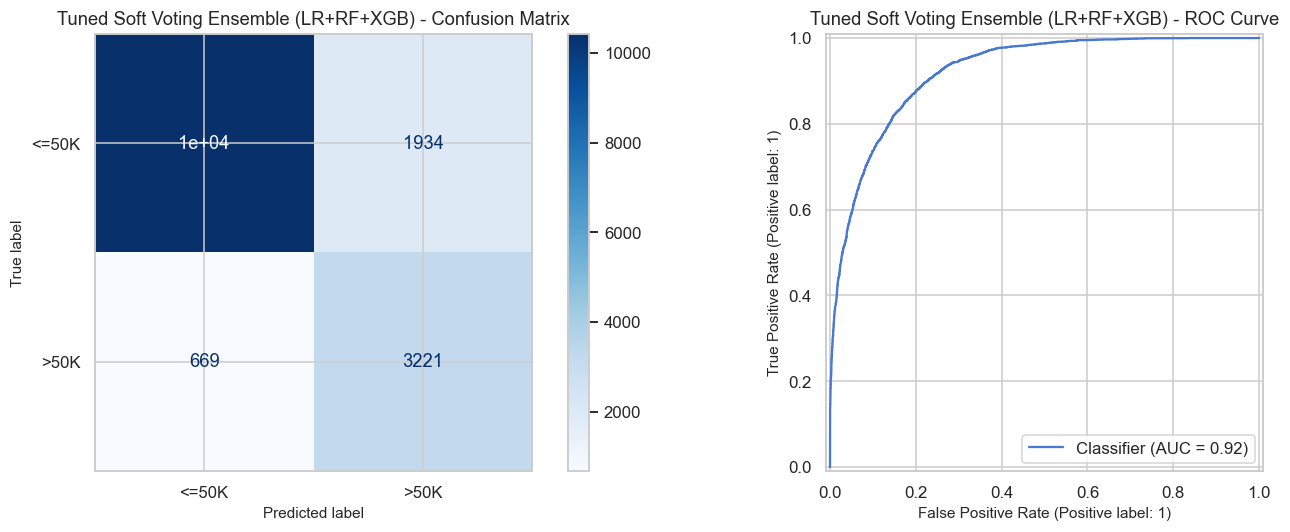

{'Model': 'Tuned Soft Voting Ensemble (LR+RF+XGB)',
 'Accuracy': 0.839795667159035,
 'Precision': np.float64(0.8643094359930625),
 'Recall': np.float64(0.839795667159035),
 'F1-Score': np.float64(0.8466775656136329),
 'ROC-AUC': np.float64(0.9224019618651947)}

In [16]:
# =============================================================================
# STEP 13 — Tuned Soft Voting Ensemble
# =============================================================================
tuned_ensemble = VotingClassifier(
    estimators=[
        ("lr",  lr_grid.best_estimator_),
        ("rf",  rf_grid.best_estimator_),
        ("xgb", xgb_grid.best_estimator_),
    ],
    voting="soft"
)
tuned_ensemble.fit(X_train, y_train)
evaluate_model(tuned_ensemble, X_test, y_test, "Tuned Soft Voting Ensemble (LR+RF+XGB)")


---
## STEP 14 — Feature Importance Analysis (Gini for RF, Gain for XGBoost)


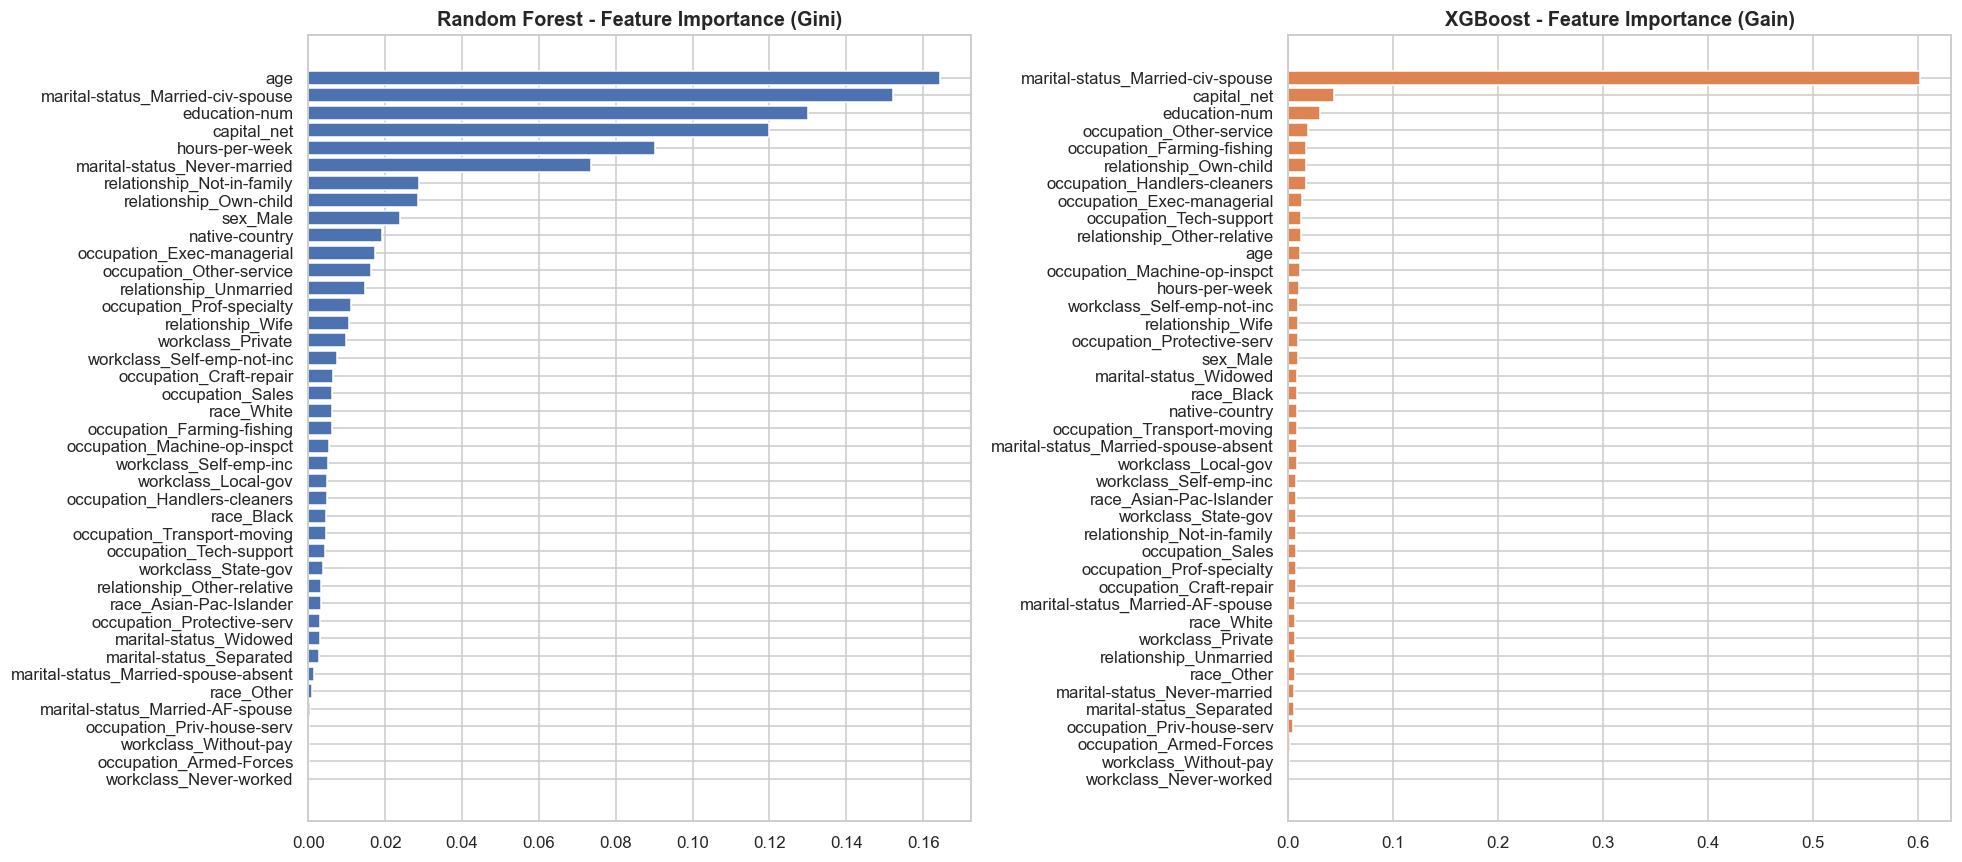


Top 5 Features (Random Forest - Gini):
                          Feature  Importance (Gini)
                              age           0.164321
marital-status_Married-civ-spouse           0.152195
                    education-num           0.130046
                      capital_net           0.119900
                   hours-per-week           0.090098

Top 5 Features (XGBoost - Gain):
                          Feature  Importance (Gain)
marital-status_Married-civ-spouse           0.602191
                      capital_net           0.043332
                    education-num           0.030606
         occupation_Other-service           0.018980
       occupation_Farming-fishing           0.017152


In [17]:
# =============================================================================
# STEP 14 — Feature Importance
# =============================================================================
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance (Gini)": rf_grid.best_estimator_.feature_importances_
}).sort_values("Importance (Gini)", ascending=False)

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance (Gain)": xgb_grid.best_estimator_.feature_importances_
}).sort_values("Importance (Gain)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(rf_importance["Feature"], rf_importance["Importance (Gini)"],
             color="#4C72B0", edgecolor="white")
axes[0].set_title("Random Forest - Feature Importance (Gini)", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()

axes[1].barh(xgb_importance["Feature"], xgb_importance["Importance (Gain)"],
             color="#DD8452", edgecolor="white")
axes[1].set_title("XGBoost - Feature Importance (Gain)", fontsize=13, fontweight="bold")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Features (Random Forest - Gini):")
print(rf_importance.head(5).to_string(index=False))
print("\nTop 5 Features (XGBoost - Gain):")
print(xgb_importance.head(5).to_string(index=False))


---
## STEP 15 — Decision Tree Rule Extraction


In [18]:
# =============================================================================
# STEP 15 — Decision Tree Rules
# =============================================================================
tree_rules = export_text(dt_grid.best_estimator_, feature_names=X_train.columns.tolist())
print(f"Decision Tree Rules (best depth={dt_grid.best_estimator_.max_depth}):")
print(tree_rules)

Decision Tree Rules (best depth=3):
|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital_net <= 0.49
|   |   |--- education-num <= 0.94
|   |   |   |--- class: 0
|   |   |--- education-num >  0.94
|   |   |   |--- class: 0
|   |--- capital_net >  0.49
|   |   |--- capital_net <= 0.82
|   |   |   |--- class: 1
|   |   |--- capital_net >  0.82
|   |   |   |--- class: 1
|--- marital-status_Married-civ-spouse >  0.50
|   |--- education-num <= -0.23
|   |   |--- capital_net <= 0.55
|   |   |   |--- class: 0
|   |   |--- capital_net >  0.55
|   |   |   |--- class: 1
|   |--- education-num >  -0.23
|   |   |--- education-num <= 0.94
|   |   |   |--- class: 1
|   |   |--- education-num >  0.94
|   |   |   |--- class: 1



---
## STEP 16 — Fairness Analysis Across Protected Attributes
Analyzing model performance across `sex`, `race` groups.


Protected attribute columns found: ['race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'sex_Male']

  Logistic Regression (Tuned)

Fairness: Logistic Regression (Tuned) by race_Asian-Pac-Islander
                        Group  Size  Accuracy  F1-Score
 race_Asian-Pac-Islander=True   504    0.7520    0.7702
race_Asian-Pac-Islander=False 15744    0.8001    0.8118

Fairness: Logistic Regression (Tuned) by race_Black
           Group  Size  Accuracy  F1-Score
 race_Black=True  1557    0.8934    0.8992
race_Black=False 14691    0.7885    0.8004

Fairness: Logistic Regression (Tuned) by race_Other
           Group  Size  Accuracy  F1-Score
 race_Other=True   139    0.8921    0.8934
race_Other=False 16109    0.7978    0.8097

Fairness: Logistic Regression (Tuned) by race_White
           Group  Size  Accuracy  F1-Score
 race_White=True 13902    0.7881    0.7997
race_White=False  2346    0.8606    0.8712

Fairness: Logistic Regression (Tuned) by sex_Male
         Group  Size 

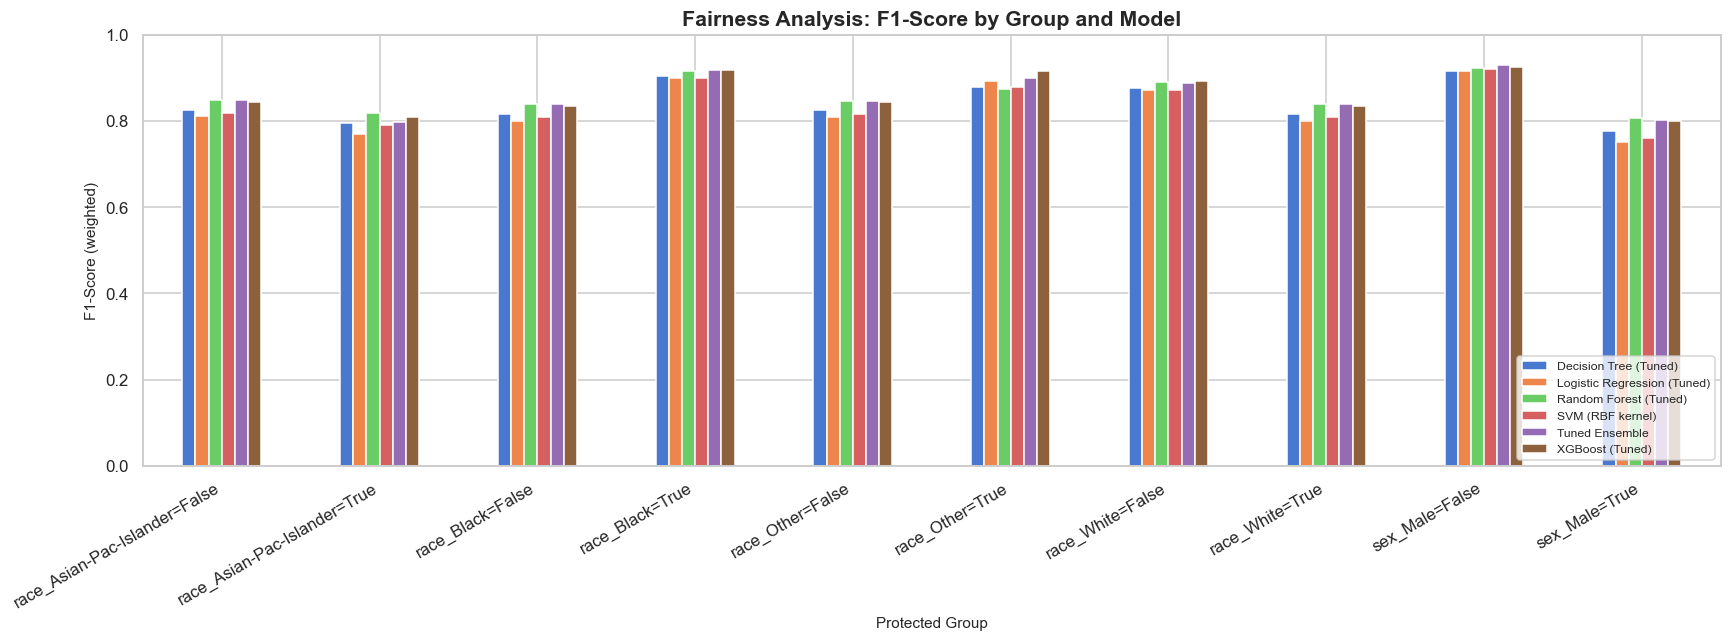

In [19]:
# =============================================================================
# STEP 16 — Fairness Analysis (All Models)
# =============================================================================
# We analyze fairness using the encoded features available in X_test.
# sex_Male=True means Male, sex_Male=False means Female
# race columns: race_White, race_Black, race_Asian-Pac-Islander, race_Other
def fairness_analysis(model, X_test_df, y_test_arr, group_col, model_name):
    """Analyze model fairness across a binary group column."""
    y_pred = model.predict(X_test_df)
    results = []
    for val in [True, False]:
        mask = X_test_df[group_col] == val
        if mask.sum() < 10:
            continue
        g_f1  = f1_score(y_test_arr[mask], y_pred[mask], average="weighted", zero_division=0)
        g_acc = accuracy_score(y_test_arr[mask], y_pred[mask])
        results.append({"Group": f"{group_col}={val}", "Size": mask.sum(),
                        "Accuracy": round(g_acc, 4), "F1-Score": round(g_f1, 4)})
    df = pd.DataFrame(results)
    print(f"\nFairness: {model_name} by {group_col}")
    print(df.to_string(index=False))
    return df

# ── Define all models to analyze ─────────────────────────────────────────────
models_for_fairness = [
    ("Logistic Regression (Tuned)", lr_grid.best_estimator_),
    ("Decision Tree (Tuned)",       dt_grid.best_estimator_),
    ("Random Forest (Tuned)",       rf_grid.best_estimator_),
    ("XGBoost (Tuned)",             xgb_grid.best_estimator_),
    ("SVM (RBF kernel)",            svm_model),
    ("Tuned Ensemble",              tuned_ensemble),
]

fair_cols = [c for c in X_test.columns if c.startswith("sex_") or c.startswith("race_")]
print(f"Protected attribute columns found: {fair_cols}")

# ── Run fairness analysis for every model and every protected attribute ───────
fairness_records = []  # collect for summary table at the end

for model_name, model in models_for_fairness:
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")
    for col in fair_cols:
        df_fair = fairness_analysis(model, X_test, y_test, col, model_name)
        for _, row in df_fair.iterrows():
            fairness_records.append({
                "Model":    model_name,
                "Group":    row["Group"],
                "Size":     row["Size"],
                "Accuracy": row["Accuracy"],
                "F1-Score": row["F1-Score"],
            })

# ── Summary table: compare all models side by side per group ─────────────────
print(f"\n{'='*70}")
print("  FAIRNESS SUMMARY — F1-Score by Model and Group")
print(f"{'='*70}")

fairness_df = pd.DataFrame(fairness_records)

# Pivot so rows = groups, columns = models — easy to compare side by side
fairness_pivot = fairness_df.pivot_table(
    index="Group", columns="Model", values="F1-Score"
)
print(fairness_pivot.round(4).to_string())

# ── Bar chart: F1 per group per model ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fairness_pivot.plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Fairness Analysis: F1-Score by Group and Model",
             fontsize=14, fontweight="bold")
ax.set_ylabel("F1-Score (weighted)")
ax.set_ylim(0, 1)
ax.set_xlabel("Protected Group")
ax.legend(loc="lower right", fontsize=8)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

---
## STEP 17 — Final Combined Model Comparison



  COMPLETE MODEL COMPARISON (Tuned Models)
                                        Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                                 
Majority-Class Baseline                   0.7606     0.5785  0.7606    0.6572   0.5000
Logistic Regression (Tuned)               0.7986     0.8479  0.7986    0.8105   0.8988
Decision Tree (Tuned)                     0.8206     0.8323  0.8206    0.8250   0.8700
SVM (RBF kernel)                          0.8064     0.8556  0.8064    0.8179   0.9012
Random Forest (Tuned)                     0.8426     0.8545  0.8426    0.8468   0.9115
XGBoost (Tuned)                           0.8364     0.8646  0.8364    0.8440   0.9268
Tuned Soft Voting Ensemble (LR+RF+XGB)    0.8398     0.8643  0.8398    0.8467   0.9224

Primary metric: F1-Score (weighted)


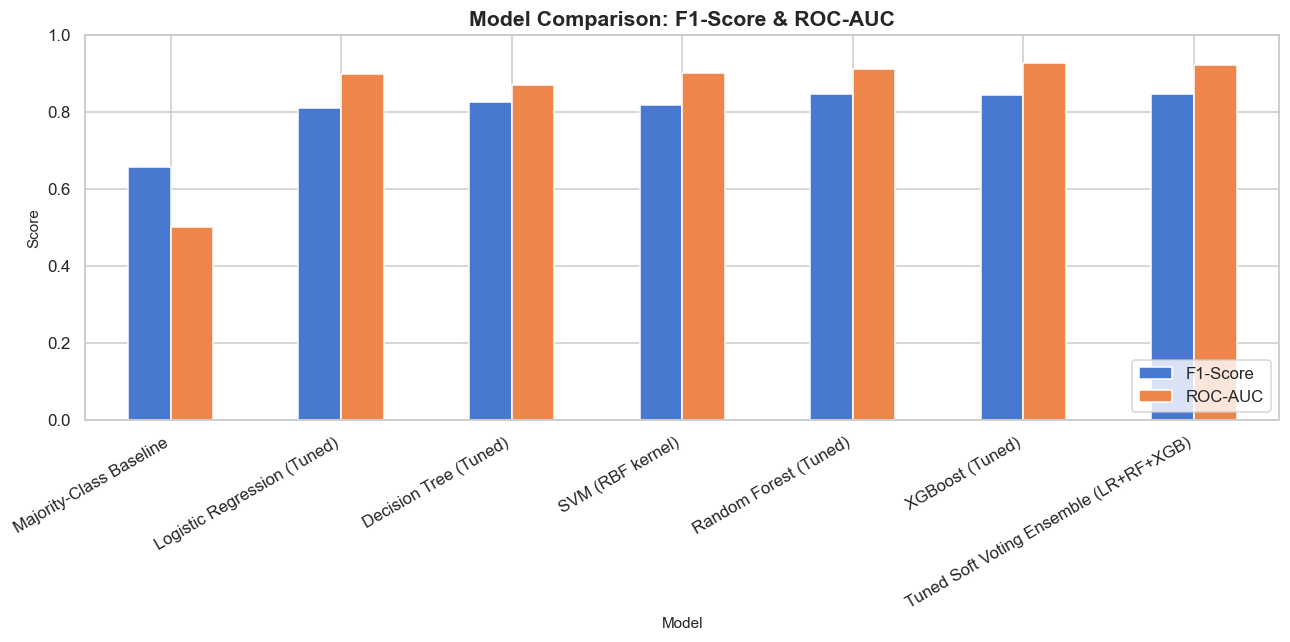

In [20]:
# =============================================================================
# STEP 17 — Final Combined Comparison
# =============================================================================
final_df = pd.DataFrame(all_results).set_index("Model")
print("\n" + "="*70)
print("  COMPLETE MODEL COMPARISON (Tuned Models)") 
print("="*70)
print(final_df.round(4).to_string())
print("\nPrimary metric: F1-Score (weighted)")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
final_df[["F1-Score", "ROC-AUC"]].plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Model Comparison: F1-Score & ROC-AUC", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
